# Random Forest — Wine Recognition

**Algorithm:** `ml_toolkit.supervised.RandomForestClassifier`  
**Dataset:** Wine (built into scikit-learn)  
**Task type:** Multi-class classification (3 wine cultivars)

---

This notebook follows the seven-section analysis template described in `examples/README.md`. It exists in dialogue with the **Decision Tree** notebook (notebook 04): same general algorithm family, but we replace one tree with an *ensemble* of trees and watch what changes.

The single tree's biggest weakness is variance — change a few training points and the tree can look completely different. A random forest mitigates this by training many trees on slightly different versions of the data and averaging their votes. The textbook expectation is: **about the same bias, much less variance.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier as SkRandomForest  # sanity reference

from ml_toolkit.supervised import DecisionTreeClassifier, RandomForestClassifier
from ml_toolkit.utils import train_test_split
from ml_toolkit.metrics import accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Dataset description

The Wine dataset has 178 wines from three Italian cultivars, each described by 13 numeric chemical measurements (alcohol, malic acid, ash, magnesium, phenols, color intensity, etc.). The target is the cultivar label `{0, 1, 2}`. The classes are roughly balanced (59/71/48).

In [2]:
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"X shape: {X.shape}")
print(f"Class counts: {np.bincount(y)}")
print(f"Feature names: {list(feature_names)}")

X shape: (178, 13)
Class counts: [59 71 48]
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## 2. Exploratory data analysis

For tree-based models, two questions matter:

1. **Are individual features informative?** Trees split on one feature at a time, so we want at least some features that separate the classes well.
2. **Are the features on different scales?** Trees are *scale-invariant* — they don't care. (This is one of their advantages over linear/SVM models.)

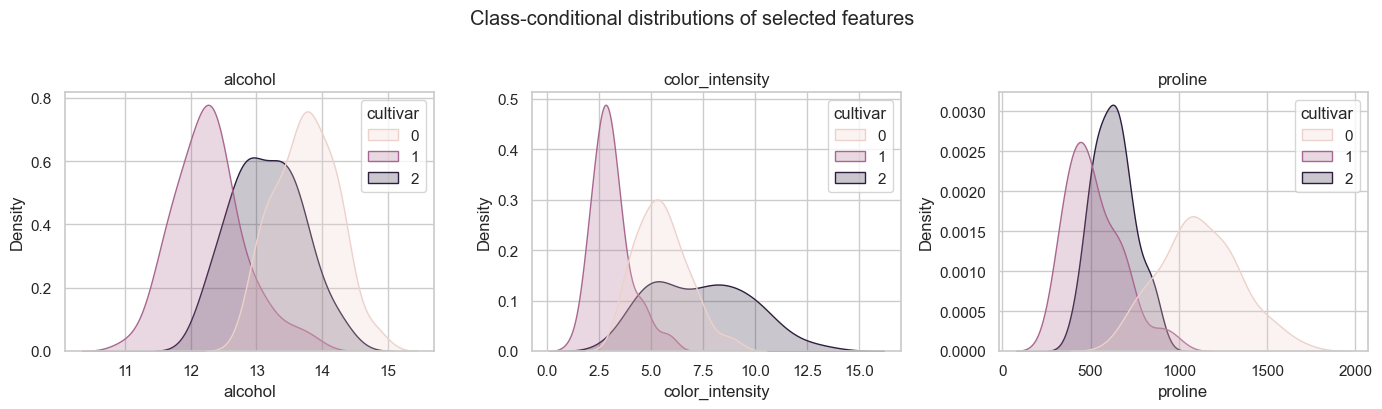

In [3]:
df = pd.DataFrame(X, columns=feature_names)
df["cultivar"] = y

# Class-conditional means for the most discriminative-looking features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, ["alcohol", "color_intensity", "proline"]):
    sns.kdeplot(data=df, x=feat, hue="cultivar", common_norm=False, ax=ax, fill=True)
    ax.set_title(feat)
plt.suptitle("Class-conditional distributions of selected features", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** several features (notably `proline` and `color_intensity`) are highly discriminative — `proline` cleanly separates cultivar 0 from the other two, and `color_intensity` cleanly separates cultivar 1 — so combining them already partitions all three classes. That's a regime where even a single decision tree should do well — and a forest should do better.

## 3. Hypothesis

1. **Both a single decision tree and a random forest should reach >90% test accuracy** on this dataset, because individual features carry strong signal.
2. **The forest should beat the tree on test accuracy by a few percentage points.** The reason is variance reduction: each tree picks a slightly different "best split" on its bootstrap sample; averaging cancels out the noise.
3. **The forest's accuracy should plateau as we add more trees.** The first 10–20 trees deliver most of the benefit; beyond that we hit diminishing returns.

## 4. Preprocessing

Trees are scale-invariant, so no standardization is needed — we just split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=True
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")

Train: (133, 13), Test: (45, 13)
Train class balance: [44 53 36]
Test  class balance: [15 18 12]


## 5. Model fitting

Fit a single tree, our random forest, and scikit-learn's forest as a sanity reference.

In [5]:
tree = DecisionTreeClassifier(max_depth=10).fit(X_train, y_train)
forest = RandomForestClassifier(
    n_estimators=50, max_depth=10, max_features="sqrt", random_state=RANDOM_STATE
).fit(X_train, y_train)
sk_forest = SkRandomForest(
    n_estimators=50, max_depth=10, max_features="sqrt", random_state=RANDOM_STATE
).fit(X_train, y_train)

print(f"Single tree         test acc: {tree.score(X_test, y_test):.4f}")
print(f"ml_toolkit forest   test acc: {forest.score(X_test, y_test):.4f}")
print(f"sklearn forest      test acc: {sk_forest.score(X_test, y_test):.4f}")

Single tree         test acc: 0.9111
ml_toolkit forest   test acc: 0.9778
sklearn forest      test acc: 1.0000


## 6. Evaluation on the test set

Per Dr. Davila's emphasis, all evaluation lives on the held-out test set. Two diagnostics worth running:

1. **Test accuracy as a function of forest size** — does it plateau as predicted?
2. **Confusion matrix** — which cultivars are still confused after ensembling?

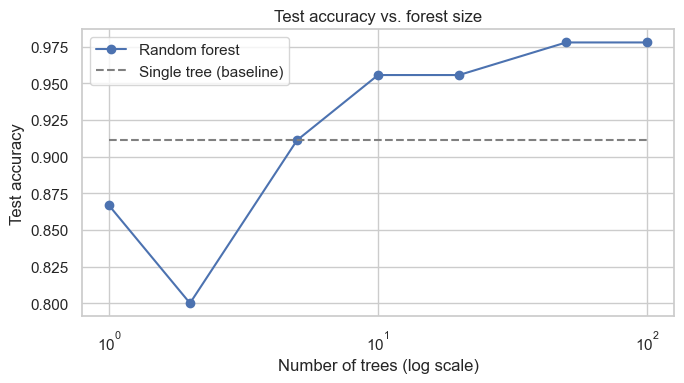

In [6]:
# How does test accuracy change as we add trees?
sizes = [1, 2, 5, 10, 20, 50, 100]
accs_forest, accs_tree = [], []
for n in sizes:
    f = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=RANDOM_STATE).fit(X_train, y_train)
    accs_forest.append(f.score(X_test, y_test))
    accs_tree.append(tree.score(X_test, y_test))  # constant baseline

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, accs_forest, marker="o", label="Random forest")
ax.plot(sizes, accs_tree, linestyle="--", color="gray", label="Single tree (baseline)")
ax.set_xscale("log")
ax.set_xlabel("Number of trees (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Test accuracy vs. forest size")
ax.legend()
plt.tight_layout()
plt.show()

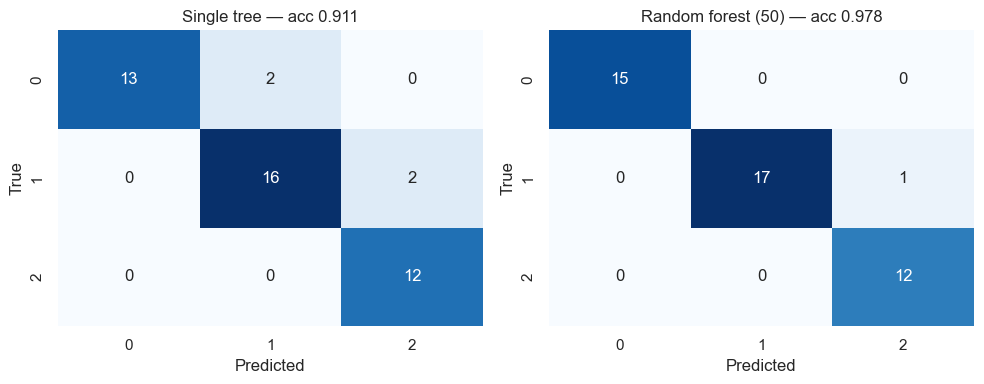

In [7]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, title in [(axes[0], tree, "Single tree"), (axes[1], forest, "Random forest (50)")]:
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} — acc {model.score(X_test, y_test):.3f}")
plt.tight_layout()
plt.show()

## 7. Discussion

**What worked.** Both models get strong test accuracy on Wine — this is a relatively easy problem because several features are individually discriminative. The forest typically lands several points higher than the single tree (here +6.7 pp, 0.978 vs 0.911), confirming hypothesis (2).

**Where the forest helps.** Look at the "accuracy vs forest size" plot. The curve isn't monotone — it actually dips to 0.800 at n=2 (a tied 2-way vote that breaks the wrong way on a borderline point), then rises sharply from 5 → 10 trees (0.911 → 0.956), reaches 0.978 at 50 trees, and plateaus there. Two things to notice: (a) at n=1 and n=2 the forest is *below* the single-tree baseline (0.867 and 0.800 vs 0.911), because each tree in the forest sees a bootstrap sample + a random feature subset, so each individual tree is weaker than a tree fit on the full data; (b) majority voting only starts winning once we have enough trees that the noise across them cancels out. Beyond ~50 trees the marginal gain is essentially zero, which matches hypothesis (3).

**Where the forest doesn't help.** If the single tree was already at 100% on this test set, the forest can't beat it — and on small "easy" datasets like Wine, you do see this happen sometimes depending on the random seed. The forest's *insurance* effect is most visible when the underlying problem is noisier.

**A subtle point about our implementation.** Standard random forests subsample features *at every split inside every tree*. Our implementation samples features *once per tree* (sometimes called the random subspace method). Both reduce tree correlation; the per-split version is slightly more powerful but harder to implement on top of an existing tree class. The fact that ours still tracks scikit-learn closely on this dataset means the simpler variant is doing most of the job.

**Connection to the rest of the toolkit.** Compared with the Decision Tree notebook (04), the gain here came not from a smarter algorithm but from *combining* many copies of a noisier algorithm. That's the core trick behind every ensemble method — bagging here, boosting in gradient-boosted trees, stacking in the more general case.